In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
sns.set_style("dark")

In [2]:
datapath = "../data/ocean_temperature.csv"

df = pd.read_csv(datapath)

In [39]:
print(df.shape)
df.head()

(19165, 5)


,date,sensor_depth_at_low_tide_m,mean_temperature_degree_c,sd_temperature_degree_c,n_obs
0,2018-02-20,2,1.584839,0.041301,31
1,2018-02-20,5,1.495161,0.042885,31
2,2018-02-20,10,1.486429,0.030672,21
3,2018-02-20,15,1.627000,0.048429,21
4,2018-02-20,20,1.843750,0.042331,32


In [21]:
df.tail()

,date,sensor_depth_at_low_tide_m,mean_temperature_degree_c,sd_temperature_degree_c,n_obs
19160,2025-12-06,10,6.959518,0.035234,56
19161,2025-12-06,15,6.889179,0.034353,56
19162,2025-12-06,20,6.838214,0.033914,56
19163,2025-12-06,30,7.315625,0.112400,56
19164,2025-12-06,40,7.452482,0.014520,56


In [26]:
df['date'] = pd.to_datetime(df['date'])

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        19165 non-null  datetime64[us]
 1   sensor_depth_at_low_tide_m  19165 non-null  int64         
 2   mean_temperature_degree_c   19165 non-null  float64       
 3   sd_temperature_degree_c     19165 non-null  float64       
 4   n_obs                       19165 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(2)
memory usage: 748.8 KB


In [51]:
df['sensor_depth_at_low_tide_m'].value_counts()

sensor_depth_at_low_tide_m
10    2847
15    2847
20    2847
30    2847
5     2656
40    2622
2     2499
Name: count, dtype: int64

In [138]:
def plot_line_graph(input_df: pd.DataFrame, year: int):
    """
    plotting date by mean temperature with a line for each sensor depth
    """
    df = input_df.copy()
    palette = sns.color_palette("mako_r", 7)
    
    fig = plt.figure(figsize=(24,6))

    sns.lineplot(data=df[df['date'].dt.year==year], x="date", y="mean_temperature_degree_c", hue="sensor_depth_at_low_tide_m", palette=palette)
    plt.ylim(0,20)
    plt.xticks(rotation=90)
    plt.show()

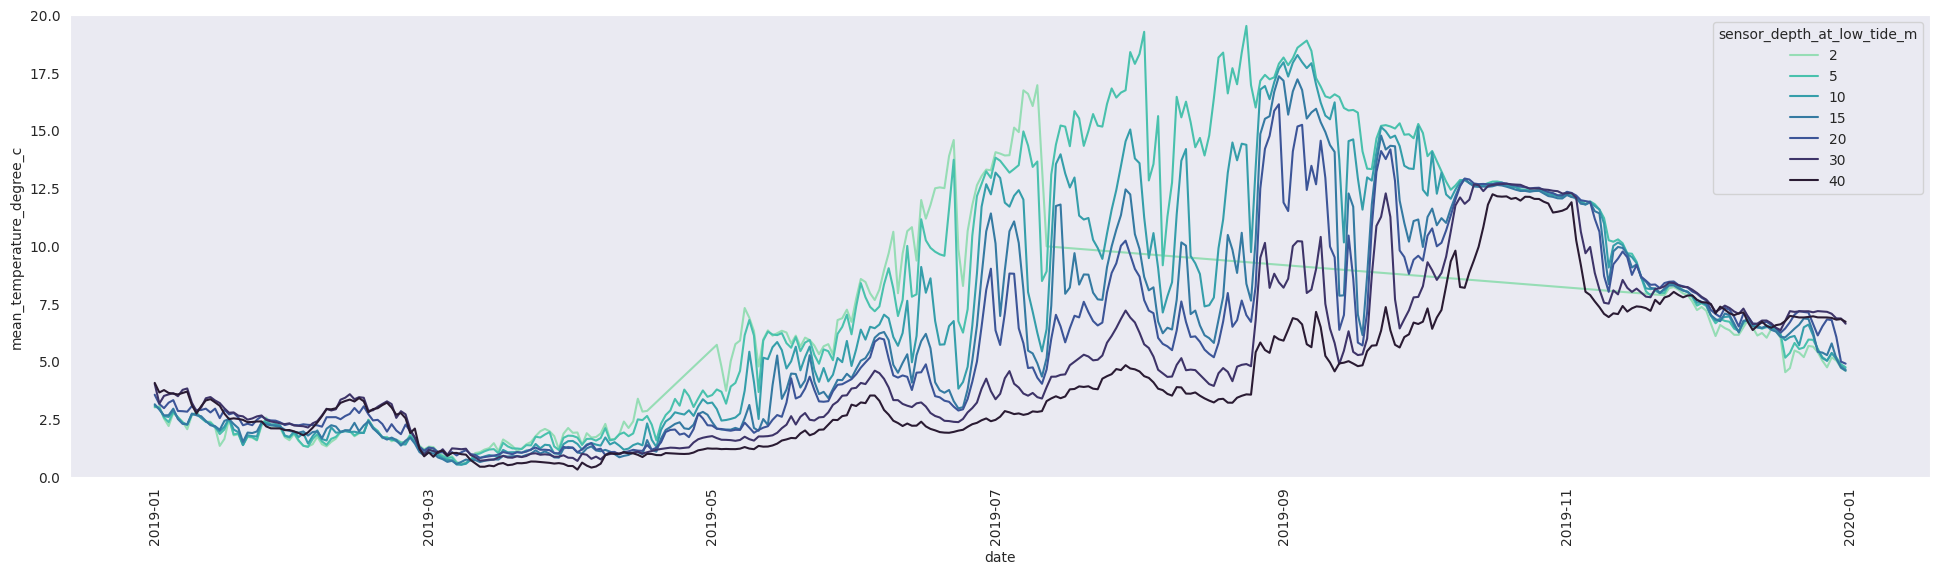

In [139]:
plot_line_graph(df, 2019)

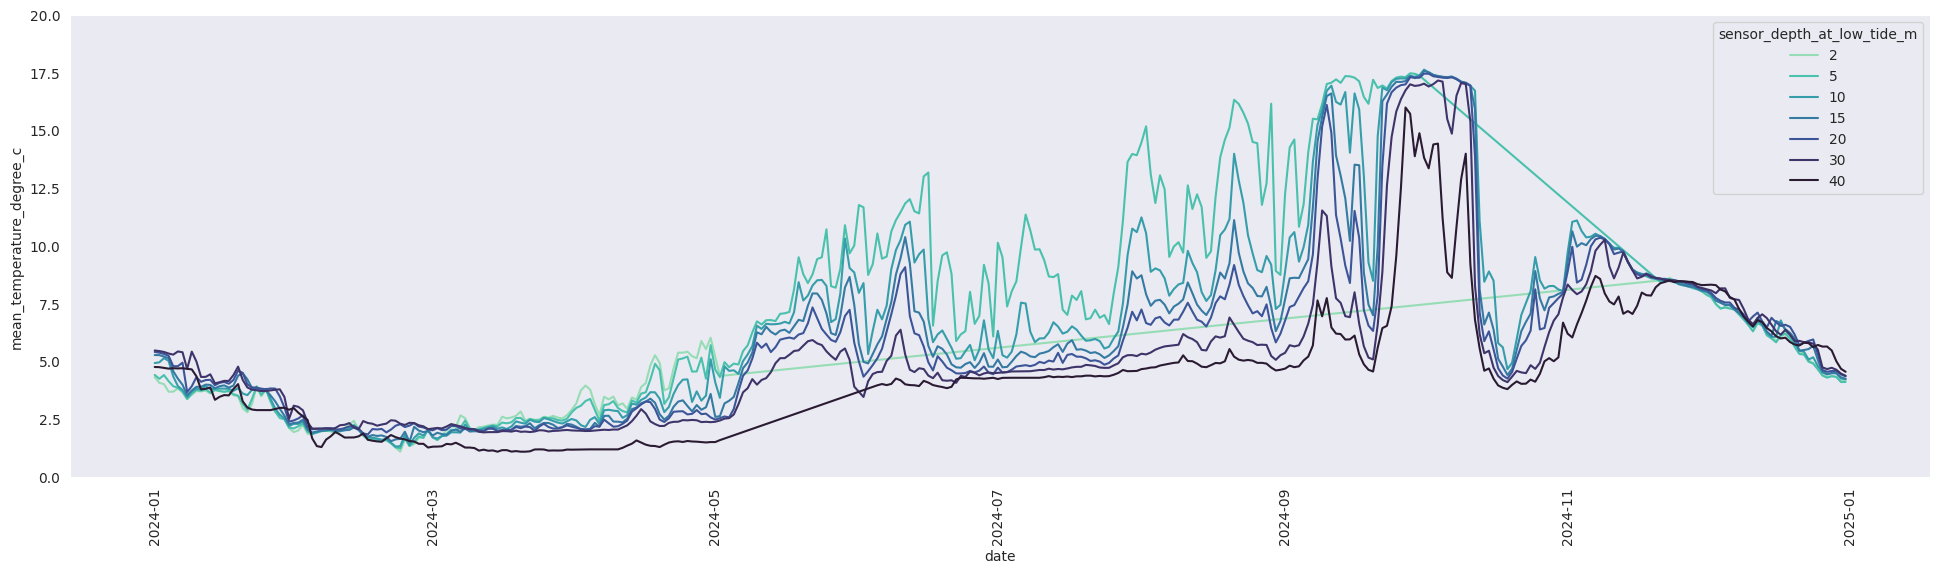

In [87]:
plot_line_graph(df, 2024)

In [122]:
def plot_years(input_df):
    df = input_df.copy()

    df = df.groupby('date')['mean_temperature_degree_c'].agg(mean="mean").reset_index()
    df['year'] = df['date'].dt.year
    df['day'] = df['date'].dt.dayofyear

    fig = plt.figure(figsize=(24, 6))
    sns.lineplot(df, x="day", y="mean", hue="year")
    
    plt.xticks(
        [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335],
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    )
    plt.show()

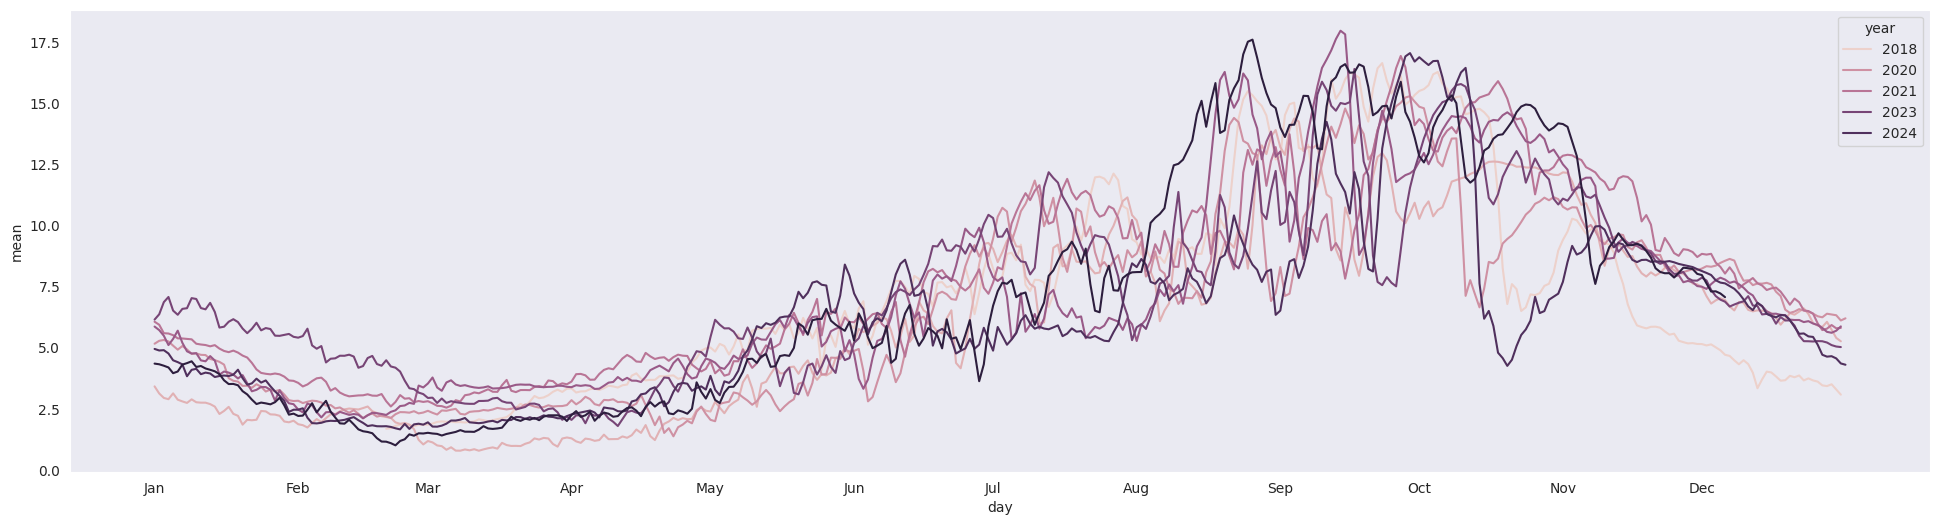

In [123]:
plot_years(df)

In [129]:
def draw_heatmap(input_df):
    df = input_df.copy()
    corrs = df.corr()

    sns.heatmap(corrs, annot=True, cmap="coolwarm")
    plt.title("Correlation Map of Columns")
    plt.show()

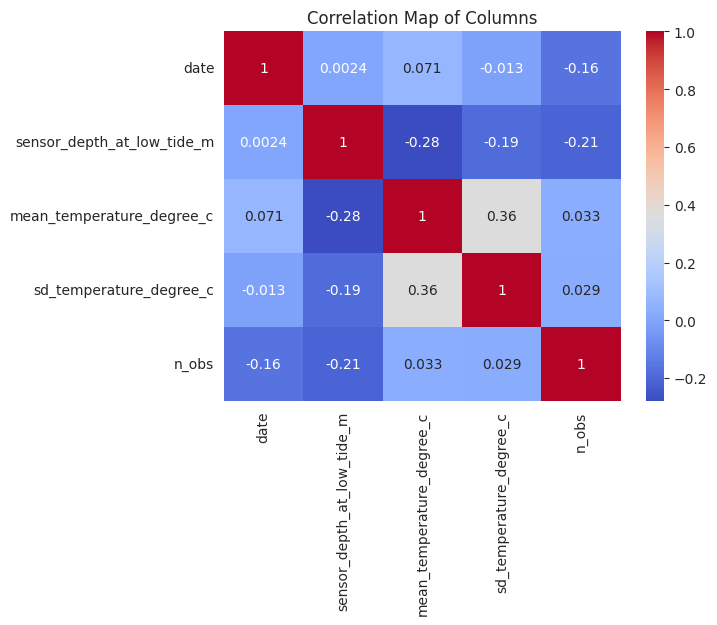

In [130]:
draw_heatmap(df)